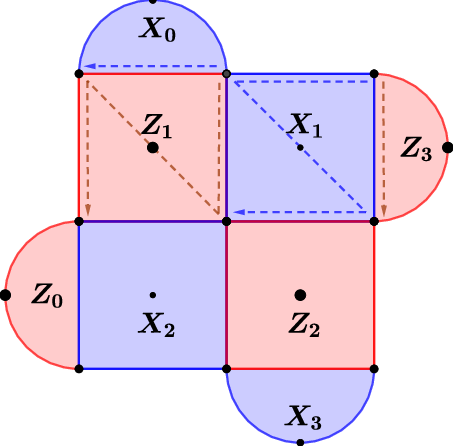

# 1️⃣ d=3 rotated surface code – “진짜 lattice 기반 wiring”
## 🔷 핵심 아이디어
- data qubit: 3×3 grid
- stabilizer: “plaquette 중심”
- 좌표 기반으로 자동 생성

## ✅ (A) 좌표 정의

In [3]:
import numpy as np

d = 3

# data qubits: (i, j)
data_coords = [(i, j) for i in range(d) for j in range(d)]

# index mapping
data_index = {coord: idx for idx, coord in enumerate(data_coords)}

## ✅ (B) stabilizer 좌표 정의

rotated surface code에서:

- Z stabilizer: (i+0.5, j+0.5)
- X stabilizer: checkerboard pattern

In [4]:
Z_stabs = []
X_stabs = []

for i in range(d-1):
    for j in range(d-1):
        if (i + j) % 2 == 0:
            Z_stabs.append((i+0.5, j+0.5))
        else:
            X_stabs.append((i+0.5, j+0.5))

## ✅ (C) stabilizer → data 연결 자동 생성

In [6]:
def get_adjacent_data(stab):
    i, j = stab
    neighbors = [
        (int(i-0.5), int(j-0.5)),
        (int(i-0.5), int(j+0.5)),
        (int(i+0.5), int(j-0.5)),
        (int(i+0.5), int(j+0.5)),
    ]
    
    return [n for n in neighbors if n in data_index]

## ✅ (D) wiring 생성

In [7]:
Z_stabilizers = [ [data_index[n] for n in get_adjacent_data(s)] for s in Z_stabs ]
X_stabilizers = [ [data_index[n] for n in get_adjacent_data(s)] for s in X_stabs ]

# 2️⃣ Pennylane 회로 (올바른 stabilizer 구조)

In [8]:
import pennylane as qml

n_data = len(data_coords)
n_anc = len(Z_stabilizers) + len(X_stabilizers)

dev = qml.device("default.mixed", wires=n_data + n_anc, shots=1)

anc_z = list(range(n_data, n_data + len(Z_stabilizers)))
anc_x = list(range(n_data + len(Z_stabilizers), n_data + n_anc))

/Users/jhan/Library/Mobile Documents/com~apple~CloudDocs/KAIST/Research/2026/1. Variational Quantum Cloning/2. 프로그래밍/Variational-Quantum-Cloning/clone_env/lib/python3.14/site-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


## stabilizer 구현

In [9]:
def apply_Z_stabilizer(anc, qubits):
    for q in qubits:
        qml.CNOT(wires=[q, anc])

def apply_X_stabilizer(anc, qubits):
    qml.Hadamard(wires=anc)
    for q in qubits:
        qml.CNOT(wires=[anc, q])
    qml.Hadamard(wires=anc)

# Main

In [10]:
@qml.qnode(dev)
def circuit(p=0.01):

    # 초기화
    for q in range(n_data):
        qml.BasisState(np.array([0]), wires=q)

    # noise
    for q in range(n_data):
        qml.DepolarizingChannel(p, wires=q)

    # Z stabilizers
    for i, stab in enumerate(Z_stabilizers):
        apply_Z_stabilizer(anc_z[i], stab)

    # X stabilizers
    for i, stab in enumerate(X_stabilizers):
        apply_X_stabilizer(anc_x[i], stab)

    return qml.sample(wires=anc_z + anc_x)

(<Figure size 2300x1400 with 1 Axes>, <Axes: >)

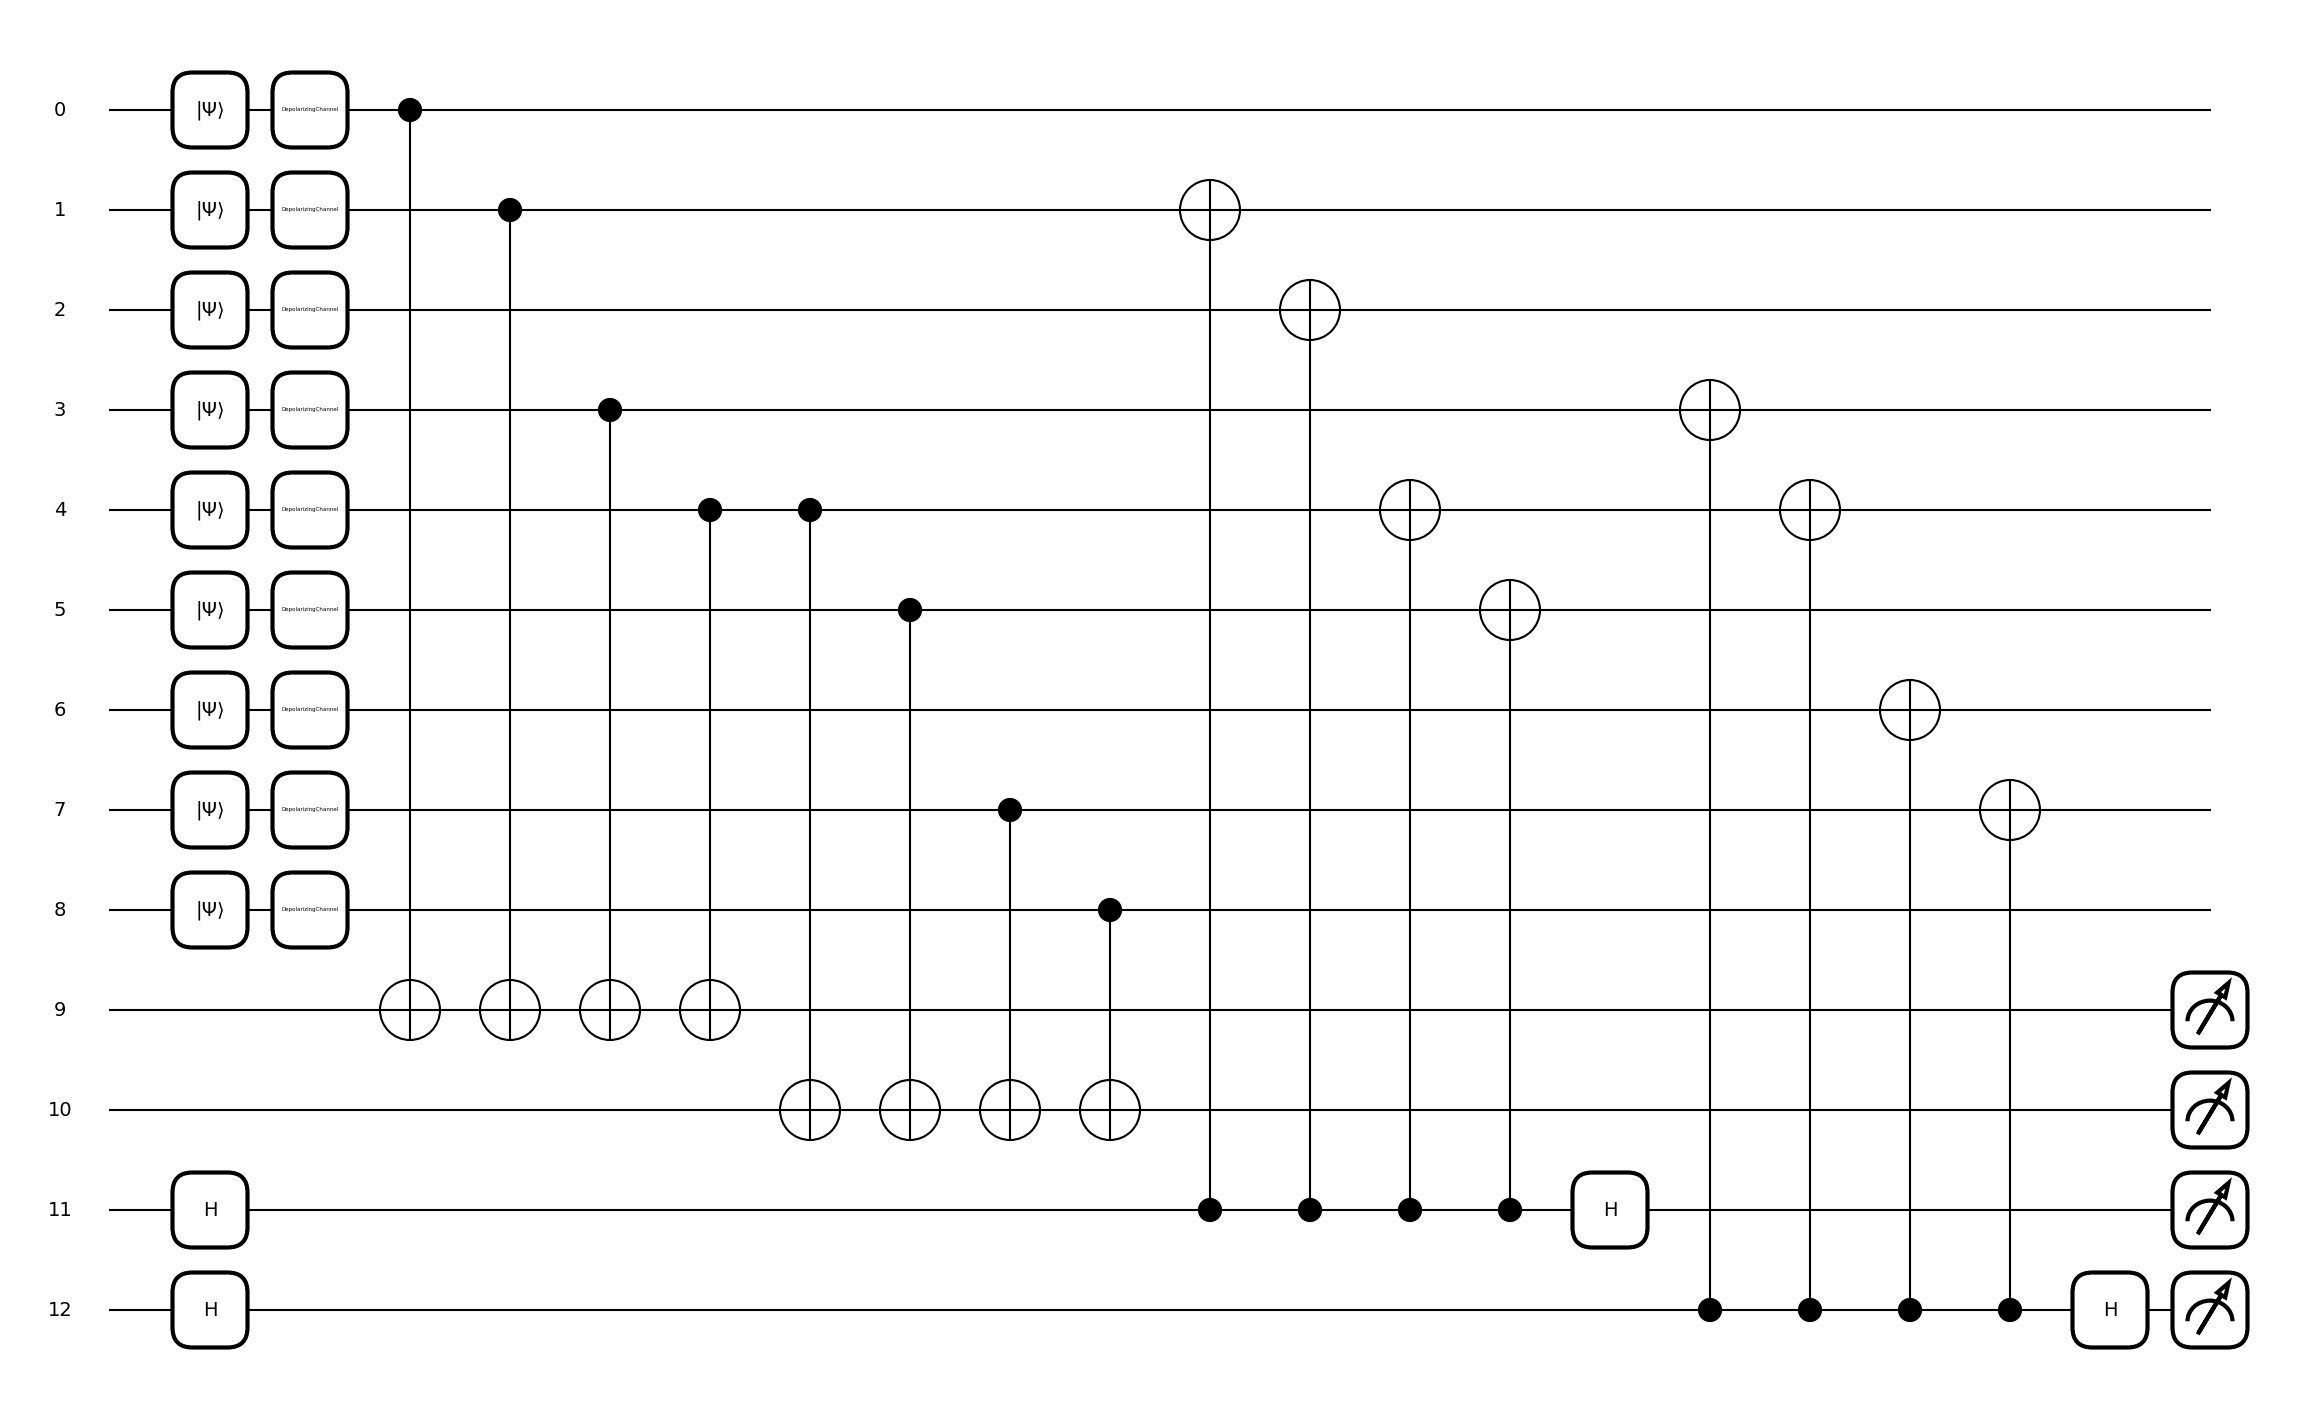

In [11]:
qml.draw_mpl(circuit)(p=0.01)

# 3️⃣ 격자 구조 시각화 (핵심)

## ✅ matplotlib 기반 lattice 시각화

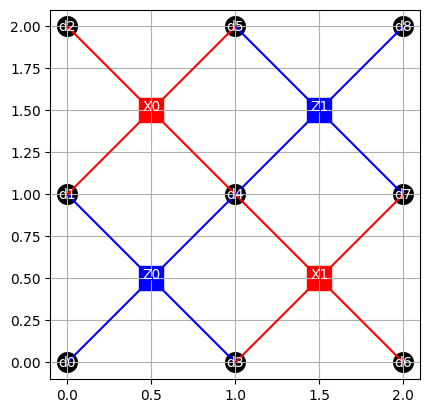

In [13]:
import matplotlib.pyplot as plt

def plot_lattice():

    fig, ax = plt.subplots()

    # data qubits
    for (i, j), idx in data_index.items():
        ax.scatter(i, j, s=200, color='black')
        ax.text(i, j, f'd{idx}', color='white', ha='center', va='center')

    # Z stabilizers
    for idx, s in enumerate(Z_stabs):
        ax.scatter(s[0], s[1], s=300, color='blue', marker='s')
        ax.text(s[0], s[1], f'Z{idx}', color='white', ha='center')

    # X stabilizers
    for idx, s in enumerate(X_stabs):
        ax.scatter(s[0], s[1], s=300, color='red', marker='s')
        ax.text(s[0], s[1], f'X{idx}', color='white', ha='center')

    # 연결선 (wiring)
    for i, stab in enumerate(Z_stabs):
        for n in get_adjacent_data(stab):
            ax.plot([stab[0], n[0]], [stab[1], n[1]], 'b-')

    for i, stab in enumerate(X_stabs):
        for n in get_adjacent_data(stab):
            ax.plot([stab[0], n[0]], [stab[1], n[1]], 'r-')

    ax.set_aspect('equal')
    plt.grid()
    plt.show()

plot_lattice()